# PIPELINE HUẤN LUYỆN MÔ HÌNH HỌC MÁY TOÀN DIỆN KHÔNG RÒ RỈ (LEAK-FREE)

Notebook này triển khai quy trình huấn luyện, tối ưu hóa siêu tham số (nested tuning) và kiểm định mô hình hồi quy dự báo tuổi thọ vòng đời pin Lithium-Ion dựa trên 4 bộ dữ liệu mới (baseline và FE cho cửa sổ 50 và 100 chu kỳ đầu đời).


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, RandomizedSearchCV, train_test_split, StratifiedShuffleSplit
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor
import warnings
warnings.filterwarnings('ignore')

# Sử dụng Path('.') để định vị tương đối thư mục hiện tại chứa dữ liệu
DATA_DIR = Path('../data/raw')
df = pd.read_csv(DATA_DIR / 'Lithium-Ion Battery Cycle Life.csv').sort_values(['battery_id', 'cycle']).reset_index(drop=True)

# Điền các giá trị cycle_life bị thiếu từ dữ liệu 100 cycle
df100 = pd.read_csv(DATA_DIR / '100_Cycle_Lithium-Ion Battery Cycle Life.csv')
mapping = df100.groupby('battery_id')['cycle_life'].median().to_dict()
df['cycle_life'] = df['cycle_life'].fillna(df['battery_id'].map(mapping))

# Lọc bỏ các dòng dữ liệu lỗi (dummy rows) có QD = 0 hoặc IR = 0
df = df[(df['QD'] > 0.0) & (df['IR'] > 0.0)].reset_index(drop=True)

WINDOW = 50
feature_base_cols = ['IR', 'QC', 'QD', 'Tavg', 'Tmin', 'Tmax', 'chargetime']


## 1. Định nghĩa các Hàm Helper cho Feature Engineering


In [2]:
def slope_first_n(s, n=WINDOW):
    values = s.head(n).dropna().to_numpy()
    if len(values) < 2:
        return np.nan
    x_norm = np.arange(len(values)) / (len(values) - 1)
    return np.polyfit(x_norm, values, 1)[0]

def curvature_first_n(s, n=WINDOW):
    values = s.head(n).dropna().to_numpy()
    if len(values) < 2:
        return np.nan
    x_norm = np.arange(len(values)) / (len(values) - 1)
    p = np.polyfit(x_norm, values, 1)
    fitted = np.polyval(p, x_norm)
    return np.mean((values - fitted) ** 2)

def delta_first_n(s, n=WINDOW):
    values = s.head(n).dropna().to_numpy()
    if len(values) < 2:
        return np.nan
    return values[-1] - values[0]

def cv_first_n(s, n=WINDOW):
    values = s.head(n).dropna().to_numpy()
    if len(values) < 2:
        return np.nan
    mean = values.mean()
    return np.nan if mean == 0 else values.std(ddof=0) / abs(mean)

def safe_div(a, b):
    if pd.isna(a) or pd.isna(b) or b == 0:
        return np.nan
    return a / b


## 2. Các đặc trưng động học đầu đời (Early Dynamic Features)


In [3]:
def early_dynamic_features(g, window):
    """
    Tính 6 Severson features từ chuỗi QD (discharge capacity) của một pin.
    g : DataFrame đã sort theo cycle, chỉ chứa dữ liệu của một battery_id
    window : int, cycle tối đa được dùng (thường = 100 theo paper)
    """
    qd_series = g[g['cycle'] >= 2]['QD'].head(window - 1).dropna().to_numpy()

    if len(qd_series) < (window - 1):
        cycle2_row = g[g['cycle'] == 2]
        dyn_ir_cycle2 = cycle2_row['IR'].iloc[0] if not cycle2_row.empty else np.nan
        if not cycle2_row.empty:
            tmax = cycle2_row['Tmax'].iloc[0]
            tavg = cycle2_row['Tavg'].iloc[0]
            dyn_temp_hetero = (tmax - tavg) if (pd.notna(tmax) and pd.notna(tavg)) else np.nan
        else:
            dyn_temp_hetero = np.nan
            
        return {
            'dyn_var_delta_qd':       np.nan,
            'dyn_mean_delta_qd':      np.nan,
            'dyn_min_delta_qd':       np.nan,
            'dyn_slope_qd':           np.nan,
            'dyn_ir_cycle2':          dyn_ir_cycle2,
            'dyn_temp_hetero_cycle2': dyn_temp_hetero,
            'dyn_ir_temp_interaction_cycle2': dyn_ir_cycle2 * dyn_temp_hetero if (pd.notna(dyn_ir_cycle2) and pd.notna(dyn_temp_hetero)) else np.nan,
        }

    delta_qd = np.diff(qd_series)
    dyn_var_delta_qd  = np.var(delta_qd, ddof=0)
    dyn_mean_delta_qd = np.mean(delta_qd)
    dyn_min_delta_qd  = np.min(delta_qd)
    x_norm = np.arange(len(qd_series)) / max(len(qd_series) - 1, 1)
    dyn_slope_qd = np.polyfit(x_norm, qd_series, 1)[0]

    cycle2_row = g[g['cycle'] == 2]
    dyn_ir_cycle2 = cycle2_row['IR'].iloc[0] if not cycle2_row.empty else np.nan

    if not cycle2_row.empty:
        tmax = cycle2_row['Tmax'].iloc[0]
        tavg = cycle2_row['Tavg'].iloc[0]
        dyn_temp_hetero = (tmax - tavg) if (pd.notna(tmax) and pd.notna(tavg)) else np.nan
    else:
        dyn_temp_hetero = np.nan

    return {
        'dyn_var_delta_qd':       dyn_var_delta_qd,
        'dyn_mean_delta_qd':      dyn_mean_delta_qd,
        'dyn_min_delta_qd':       dyn_min_delta_qd,
        'dyn_slope_qd':           dyn_slope_qd,
        'dyn_ir_cycle2':          dyn_ir_cycle2,
        'dyn_temp_hetero_cycle2': dyn_temp_hetero,
        'dyn_ir_temp_interaction_cycle2': dyn_ir_cycle2 * dyn_temp_hetero if (pd.notna(dyn_ir_cycle2) and pd.notna(dyn_temp_hetero)) else np.nan,
    }


## 3. Lọc bất thường IQR cấp độ pin & Trích xuất Đặc trưng nâng cao


In [4]:
def apply_iqr_flags_per_battery(frame, cols):
    result = frame.copy()
    q1 = result.groupby('battery_id')[cols].transform(lambda s: s.quantile(0.25))
    q3 = result.groupby('battery_id')[cols].transform(lambda s: s.quantile(0.75))
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    flag_cols = []
    for col in cols:
        flag = result[col].lt(lower[col]) | result[col].gt(upper[col])
        flag_col = f'{col.lower()}_iqr_outlier'
        result[flag_col] = flag
        flag_cols.append(flag_col)
    result['n_measurement_outlier_flags'] = result[flag_cols].sum(axis=1)
    return result

def extract_battery_features(frame, window, include_extended=False):
    base_cols = ['IR', 'QC', 'QD', 'Tavg', 'Tmin', 'Tmax', 'chargetime'] if include_extended else ['IR', 'QC', 'QD', 'Tavg', 'chargetime']
    
    rows = []
    for battery_id, g in frame.sort_values(['battery_id', 'cycle']).groupby('battery_id'):
        g = g[g['cycle_life'].notna()].sort_values('cycle')
        if g.empty:
            continue
        row = {'battery_id': battery_id, 'cycle_life': g['cycle_life'].iloc[0]}
        if not include_extended:
            row['window'] = window
            
        suffix = '_w' if include_extended else ''
        
        for col in base_cols:
            s = g[col].head(window)
            prefix = col.lower()
            row[f'{prefix}_mean{suffix}'] = s.mean()
            
            if include_extended:
                row[f'{prefix}_std{suffix}'] = s.std()
                row[f'{prefix}_min{suffix}'] = s.min()
                row[f'{prefix}_max{suffix}'] = s.max()
                row[f'{prefix}_slope{suffix}'] = slope_first_n(g[col], window)
                row[f'{prefix}_delta{suffix}'] = delta_first_n(g[col], window)
                row[f'{prefix}_cv{suffix}'] = cv_first_n(g[col], window)
            else:
                row[f'{prefix}_slope{suffix}'] = slope_first_n(g[col], window)
                
        if include_extended:
            row['temp_range_mean_w'] = row['tmax_mean_w'] - row['tmin_mean_w']
            row['qd_qc_ratio_w'] = safe_div(row['qd_mean_w'], row['qc_mean_w'])
            row['ir_qd_ratio_w'] = safe_div(row['ir_mean_w'], row['qd_mean_w'])
            
            cycle2_rows = g[g['cycle'] == 2]
            row['ir_cycle2'] = cycle2_rows['IR'].iloc[0] if not cycle2_rows.empty else np.nan
            if not cycle2_rows.empty:
                tmax_c2 = cycle2_rows['Tmax'].iloc[0]
                tavg_c2 = cycle2_rows['Tavg'].iloc[0]
                row['temp_hetero_cycle2'] = (tmax_c2 - tavg_c2) if (pd.notna(tmax_c2) and pd.notna(tavg_c2)) else np.nan
            else:
                row['temp_hetero_cycle2'] = np.nan
                
            row['ir_temp_interaction_cycle2'] = row['ir_cycle2'] * row['temp_hetero_cycle2'] if (pd.notna(row['ir_cycle2']) and pd.notna(row['temp_hetero_cycle2'])) else np.nan
            row['ir_temp_interaction_w'] = row['ir_mean_w'] * row['tavg_mean_w'] if (pd.notna(row['ir_mean_w']) and pd.notna(row['tavg_mean_w'])) else np.nan
            row['energy_accum_w'] = g['QC'].head(window).sum() + g['QD'].head(window).sum()
            row['qd_curvature_w'] = curvature_first_n(g['QD'], window)
            
            row.update(early_dynamic_features(g, 100))
        else:
            row['qd_qc_ratio'] = row['qd_mean'] / row['qc_mean'] if row['qc_mean'] != 0 else np.nan
            row['ir_qd_ratio'] = row['ir_mean'] / row['qd_mean'] if row['qd_mean'] != 0 else np.nan
            
        rows.append(row)
    return pd.DataFrame(rows).dropna() if not include_extended else pd.DataFrame(rows)

def engineer_features_for_batteries(battery_ids, raw_df, window=WINDOW):
    sub_df = raw_df[raw_df['battery_id'].isin(battery_ids)].copy()
    df_raw_window = sub_df.sort_values(['battery_id', 'cycle']).groupby('battery_id').head(window).copy()
    df_flagged_w = apply_iqr_flags_per_battery(df_raw_window, feature_base_cols)
    
    outlier_battery_features = (
        df_flagged_w.assign(is_any_measurement_outlier=df_flagged_w['n_measurement_outlier_flags'].gt(0))
        .groupby('battery_id')
        .agg(
            outlier_rate_w=('is_any_measurement_outlier', 'mean'),
            max_outlier_flags_w=('n_measurement_outlier_flags', 'max'),
        )
    )
    
    engineered = extract_battery_features(sub_df, window, include_extended=True)
    engineered = engineered.merge(outlier_battery_features.reset_index(), on='battery_id', how='left')
    return engineered


## 4. Phân chia tập độc lập Holdout Test Set & Trích xuất Đặc trưng cho 2 Cửa sổ (50 & 100)


In [5]:
print("1. Đang chia tách dữ liệu tập huấn luyện và tập kiểm thử độc lập (Holdout - Stratified)...")
all_batteries = df[df['cycle_life'].notna()]['battery_id'].unique()

# Lấy cycle_life tương ứng với từng battery_id để tính quartile bins làm stratified split
battery_life_map = df.groupby('battery_id')['cycle_life'].first()
battery_lives = np.array([battery_life_map[bid] for bid in all_batteries])
bins = pd.qcut(battery_lives, q=4, labels=False, duplicates='drop')

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(sss.split(all_batteries, bins))
train_batteries = all_batteries[train_idx]
test_batteries = all_batteries[test_idx]

print(f"Tổng số pin có sẵn: {len(all_batteries)}")
print(f"Số pin trong tập Train (để chạy CV + Tuning): {len(train_batteries)}")
print(f"Số pin trong tập Test Holdout (để đánh giá cuối cùng): {len(test_batteries)}")

print("Đang trích xuất đặc trưng cho WINDOW = 50...")
df_train_feats_50 = engineer_features_for_batteries(train_batteries, df, window=50)
df_test_feats_50 = engineer_features_for_batteries(test_batteries, df, window=50)

print("Đang trích xuất đặc trưng cho WINDOW = 100...")
df_train_feats_100 = engineer_features_for_batteries(train_batteries, df, window=100)
df_test_feats_100 = engineer_features_for_batteries(test_batteries, df, window=100)


1. Đang chia tách dữ liệu tập huấn luyện và tập kiểm thử độc lập (Holdout - Stratified)...
Tổng số pin có sẵn: 140
Số pin trong tập Train (để chạy CV + Tuning): 112
Số pin trong tập Test Holdout (để đánh giá cuối cùng): 28
Đang trích xuất đặc trưng cho WINDOW = 50...
Đang trích xuất đặc trưng cho WINDOW = 100...


## 5. Định nghĩa Hàm lựa chọn Đặc trưng & Cấu hình Không gian tìm kiếm Siêu tham số


In [6]:
def select_features_correlation(df_train_sub, collinearity_threshold=0.90, correlation_threshold=0.40):
    features_only = df_train_sub.drop(columns=['battery_id', 'cycle_life'])
    var_filter = features_only.var() > 1e-6
    features_filtered = features_only.loc[:, var_filter]
    
    corr_p = features_filtered.corrwith(df_train_sub['cycle_life'], method='pearson')
    corr_s = features_filtered.corrwith(df_train_sub['cycle_life'], method='spearman')
    composite_corr = pd.DataFrame({
        'composite': np.maximum(corr_p.abs(), corr_s.abs())
    })
    
    ordered_features = composite_corr.sort_values('composite', ascending=False).index.tolist()
    features_ordered = features_filtered[ordered_features]
    col_corr_matrix = features_ordered.corr().abs()
    
    to_drop = set()
    for i in range(len(ordered_features)):
        feat_i = ordered_features[i]
        if feat_i in to_drop:
            continue
        for j in range(i + 1, len(ordered_features)):
            feat_j = ordered_features[j]
            if feat_j in to_drop:
                continue
            if col_corr_matrix.loc[feat_i, feat_j] > collinearity_threshold:
                to_drop.add(feat_j)
                
    features_non_collinear = features_ordered.drop(columns=list(to_drop))
    selected_corr = composite_corr.loc[features_non_collinear.columns]
    selected_features = selected_corr[selected_corr['composite'] >= correlation_threshold].index.tolist()
    
    if len(selected_features) < 5:
        selected_features = selected_corr.nlargest(10, 'composite').index.tolist()
    return selected_features

param_grids = {
    'Random Forest': {
        'model': RandomForestRegressor(random_state=42),
        'grid': {
            'n_estimators': [50, 100, 200],
            'max_depth': [2, 3, 5, 7, None],
            'min_samples_split': [2, 5, 10],
            'max_features': ['sqrt', 'log2', 0.3, 0.5],
            'max_samples': [0.7, 0.8, None]
        }
    },
    'AdaBoost': {
        'model': AdaBoostRegressor(random_state=42),
        'grid': {
            'n_estimators': [50, 100, 200],
            'learning_rate': [0.01, 0.05, 0.1, 0.5]
        }
    },
    'LightGBM': {
        'model': lgb.LGBMRegressor(random_state=42, verbose=-1, n_jobs=1),
        'grid': {
            'n_estimators': [50, 100, 200],
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [2, 3, 5, 7],
            'num_leaves': [7, 15, 31],
            'reg_alpha': [0.0, 0.1, 1.0],
            'reg_lambda': [0.0, 0.1, 1.0],
            'subsample': [0.7, 0.8, 1.0],
            'colsample_bytree': [0.5, 0.7, 0.9]
        }
    },
    'XGBoost': {
        'model': xgb.XGBRegressor(random_state=42, verbosity=0, n_jobs=1),
        'grid': {
            'n_estimators': [50, 100, 200],
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [2, 3, 5, 7],
            'reg_alpha': [0.0, 0.1, 1.0],
            'reg_lambda': [0.0, 0.1, 1.0],
            'subsample': [0.7, 0.8, 1.0],
            'colsample_bytree': [0.5, 0.7, 0.9]
        }
    },
    'CatBoost': {
        'model': CatBoostRegressor(random_state=42, verbose=0, thread_count=1),
        'grid': {
            'iterations': [50, 100, 200],
            'learning_rate': [0.01, 0.05, 0.1],
            'depth': [2, 3, 5, 7],
            'l2_leaf_reg': [1, 3, 5, 10],
            'subsample': [0.7, 0.8, 1.0]
        }
    }
}


## 6. Huấn luyện 5-Fold Cross-Validation sạch & Tối ưu siêu tham số (Nested CV)


In [7]:
print("2. Đang thực hiện 5-Fold Cross-Validation sạch (Không rò rỉ đặc trưng)...")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
datasets_names = ['1_baseline_w50', '2_fe_w50', '3_baseline_w100', '4_fe_w100']

cv_results = []

for ds_name in datasets_names:
    print(f"\n[Dataset: {ds_name}]")
    
    if 'w50' in ds_name:
        df_train_feats_ds = df_train_feats_50.copy()
        df_test_feats_ds = df_test_feats_50.copy()
    else:
        df_train_feats_ds = df_train_feats_100.copy()
        df_test_feats_ds = df_test_feats_100.copy()
        
    y_train_all = df_train_feats_ds['cycle_life']
    
    oof_predictions = {}
    model_rmse_folds = {m: [] for m in param_grids}
    
    for model_name, config in param_grids.items():
        oof_preds = np.zeros(len(df_train_feats_ds))
        
        for fold, (train_idx, val_idx) in enumerate(kf.split(df_train_feats_ds, y_train_all)):
            df_fold_train = df_train_feats_ds.iloc[train_idx]
            df_fold_val = df_train_feats_ds.iloc[val_idx]
            y_fold_tr = df_fold_train['cycle_life']
            y_fold_va = df_fold_val['cycle_life']
            
            # Feature selection strictly on training fold
            if 'baseline' in ds_name:
                selected_features = [c.lower() + '_mean_w' for c in ['IR', 'QC', 'QD', 'Tavg', 'chargetime']]
            else:
                selected_features = select_features_correlation(df_fold_train)
                
            X_fold_tr = df_fold_train[selected_features]
            X_fold_va = df_fold_val[selected_features]
            
            # Tuning inside fold
            search = RandomizedSearchCV(
                estimator=config['model'],
                param_distributions=config['grid'],
                n_iter=8,
                scoring='neg_mean_squared_error',
                cv=5,
                random_state=42,
                n_jobs=-1
            )
            search.fit(X_fold_tr, y_fold_tr)
            best_model = search.best_estimator_
            
            fold_preds = best_model.predict(X_fold_va)
            oof_preds[val_idx] = fold_preds
            
            # Save fold-level RMSE for confidence intervals
            fold_rmse = np.sqrt(mean_squared_error(y_fold_va, fold_preds))
            model_rmse_folds[model_name].append(fold_rmse)
            
        rmse_val = np.sqrt(mean_squared_error(y_train_all, oof_preds))
        mae_val = mean_absolute_error(y_train_all, oof_preds)
        mape_val = mean_absolute_percentage_error(y_train_all, oof_preds) * 100
        r2_val = r2_score(y_train_all, oof_preds)
        rmse_std = np.std(model_rmse_folds[model_name])
        
        oof_predictions[model_name] = oof_preds
        
        print(f"  {model_name:15s} - RMSE: {rmse_val:.2f} ± {rmse_std:.2f}, MAE: {mae_val:.2f}, MAPE: {mape_val:.2f}%, R2: {r2_val:.3f}")
        
        cv_results.append({
            'Dataset': ds_name,
            'Model': model_name,
            'CV_RMSE_mean': rmse_val,
            'CV_RMSE_std': rmse_std,
            'CV_MAE': mae_val,
            'CV_MAPE': mape_val,
            'CV_R2': r2_val,
            'OOF_Predictions': oof_preds
        })
        
    # Ensemble (Top-3 models based on CV RMSE)
    sorted_models = sorted(model_rmse_folds.items(), key=lambda x: np.mean(x[1]))
    top_3_models = [m[0] for m in sorted_models[:3]]
    
    ensemble_preds = np.mean([oof_predictions[m] for m in top_3_models], axis=0)
    ens_rmse = np.sqrt(mean_squared_error(y_train_all, ensemble_preds))
    ens_mae = mean_absolute_error(y_train_all, ensemble_preds)
    ens_mape = mean_absolute_percentage_error(y_train_all, ensemble_preds) * 100
    ens_r2 = r2_score(y_train_all, ensemble_preds)
    
    ens_fold_rmses = []
    for fold, (train_idx, val_idx) in enumerate(kf.split(df_train_feats_ds, y_train_all)):
        y_fold_va = y_train_all.iloc[val_idx]
        fold_ens_preds = ensemble_preds[val_idx]
        ens_fold_rmses.append(np.sqrt(mean_squared_error(y_fold_va, fold_ens_preds)))
    ens_rmse_std = np.std(ens_fold_rmses)
    
    print(f"  Ensemble (Top-3) - RMSE: {ens_rmse:.2f} ± {ens_rmse_std:.2f}, MAE: {ens_mae:.2f}, MAPE: {ens_mape:.2f}%, R2: {ens_r2:.3f} (Dựa trên: {top_3_models})")
    
    cv_results.append({
        'Dataset': ds_name,
        'Model': 'Ensemble (Top-3)',
        'CV_RMSE_mean': ens_rmse,
        'CV_RMSE_std': ens_rmse_std,
        'CV_MAE': ens_mae,
        'CV_MAPE': ens_mape,
        'CV_R2': ens_r2,
        'OOF_Predictions': ensemble_preds,
        'Top_3_Models': top_3_models
    })


2. Đang thực hiện 5-Fold Cross-Validation sạch (Không rò rỉ đặc trưng)...

[Dataset: 1_baseline_w50]
  Random Forest   - RMSE: 246.03 ± 56.97, MAE: 172.37, MAPE: 24.83%, R2: 0.446
  AdaBoost        - RMSE: 246.86 ± 59.56, MAE: 170.33, MAPE: 23.25%, R2: 0.442
  LightGBM        - RMSE: 246.49 ± 51.95, MAE: 177.18, MAPE: 24.18%, R2: 0.444
  XGBoost         - RMSE: 253.47 ± 63.19, MAE: 183.10, MAPE: 25.27%, R2: 0.412
  CatBoost        - RMSE: 252.66 ± 60.04, MAE: 176.88, MAPE: 24.49%, R2: 0.416
  Ensemble (Top-3) - RMSE: 240.43 ± 55.83, MAE: 168.00, MAPE: 23.34%, R2: 0.471 (Dựa trên: ['Random Forest', 'AdaBoost', 'LightGBM'])

[Dataset: 2_fe_w50]
  Random Forest   - RMSE: 215.63 ± 56.40, MAE: 143.63, MAPE: 19.00%, R2: 0.574
  AdaBoost        - RMSE: 211.86 ± 45.75, MAE: 141.59, MAPE: 18.65%, R2: 0.589
  LightGBM        - RMSE: 223.93 ± 40.89, MAE: 153.56, MAPE: 19.72%, R2: 0.541
  XGBoost         - RMSE: 218.44 ± 46.54, MAE: 137.92, MAPE: 16.90%, R2: 0.563
  CatBoost        - RMSE: 221.79 

## 7. Đánh giá mô hình tối ưu trên tập kiểm thử độc lập Holdout Test Set


In [8]:
print("3. Đang đánh giá cuối cùng trên tập độc lập Holdout Test Set (28 pin)...")
test_results = []
final_best_rf_model = None
final_best_rf_features = None

for ds_name in datasets_names:
    print(f"\n[Evaluating Dataset: {ds_name} on Holdout Test Split]")
    
    if 'w50' in ds_name:
        df_train_feats_ds = df_train_feats_50.copy()
        df_test_feats_ds = df_test_feats_50.copy()
    else:
        df_train_feats_ds = df_train_feats_100.copy()
        df_test_feats_ds = df_test_feats_100.copy()
        
    y_train = df_train_feats_ds['cycle_life']
    y_test = df_test_feats_ds['cycle_life']
    
    if 'baseline' in ds_name:
        selected_features = [c.lower() + '_mean_w' for c in ['IR', 'QC', 'QD', 'Tavg', 'chargetime']]
    else:
        selected_features = select_features_correlation(df_train_feats_ds)
        
    X_train = df_train_feats_ds[selected_features]
    X_test = df_test_feats_ds[selected_features]
    
    test_preds_dict = {}
    
    # Train each model on full training set
    for model_name, config in param_grids.items():
        cv_item = next(item for item in cv_results if item['Dataset'] == ds_name and item['Model'] == model_name)
        
        search = RandomizedSearchCV(
            estimator=config['model'],
            param_distributions=config['grid'],
            n_iter=8,
            scoring='neg_mean_squared_error',
            cv=5,
            random_state=42,
            n_jobs=-1
        )
        search.fit(X_train, y_train)
        best_model = search.best_estimator_
        
        # Track best model on origin + FE dataset for feature importance plotting
        if ds_name == '4_fe_w100' and model_name == 'Random Forest':
            final_best_rf_model = best_model
            final_best_rf_features = selected_features
            
        test_preds = best_model.predict(X_test)
        test_preds_dict[model_name] = test_preds
        
        test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
        test_mae = mean_absolute_error(y_test, test_preds)
        test_mape = mean_absolute_percentage_error(y_test, test_preds) * 100
        test_r2 = r2_score(y_test, test_preds)
        
        print(f"  {model_name:15s} - Test RMSE: {test_rmse:.2f}, Test MAE: {test_mae:.2f}, Test MAPE: {test_mape:.2f}%, Test R2: {test_r2:.3f}")
        
        test_results.append({
            'Dataset': ds_name,
            'Model': model_name,
            'CV_RMSE_mean': cv_item['CV_RMSE_mean'],
            'CV_RMSE_std': cv_item['CV_RMSE_std'],
            'CV_MAPE': cv_item['CV_MAPE'],
            'Test_RMSE': test_rmse,
            'Test_MAE': test_mae,
            'Test_MAPE': test_mape,
            'Test_R2': test_r2,
            'Test_Predictions': test_preds
        })
        
    # Evaluate Ensemble on Test set
    cv_ens_item = next(item for item in cv_results if item['Dataset'] == ds_name and item['Model'] == 'Ensemble (Top-3)')
    top_3_models = cv_ens_item['Top_3_Models']
    
    ens_test_preds = np.mean([test_preds_dict[m] for m in top_3_models], axis=0)
    ens_test_rmse = np.sqrt(mean_squared_error(y_test, ens_test_preds))
    ens_test_mae = mean_absolute_error(y_test, ens_test_preds)
    ens_test_mape = mean_absolute_percentage_error(y_test, ens_test_preds) * 100
    ens_test_r2 = r2_score(y_test, ens_test_preds)
    
    print(f"  Ensemble (Top-3) - Test RMSE: {ens_test_rmse:.2f}, Test MAE: {ens_test_mae:.2f}, Test MAPE: {ens_test_mape:.2f}%, Test R2: {ens_test_r2:.3f} (Dựa trên: {top_3_models})")
    
    test_results.append({
        'Dataset': ds_name,
        'Model': 'Ensemble (Top-3)',
        'CV_RMSE_mean': cv_ens_item['CV_RMSE_mean'],
        'CV_RMSE_std': cv_ens_item['CV_RMSE_std'],
        'CV_MAPE': cv_ens_item['CV_MAPE'],
        'Test_RMSE': ens_test_rmse,
        'Test_MAE': ens_test_mae,
        'Test_MAPE': ens_test_mape,
        'Test_R2': ens_test_r2,
        'Test_Predictions': ens_test_preds
    })


3. Đang đánh giá cuối cùng trên tập độc lập Holdout Test Set (28 pin)...

[Evaluating Dataset: 1_baseline_w50 on Holdout Test Split]
  Random Forest   - Test RMSE: 206.15, Test MAE: 145.08, Test MAPE: 25.96%, Test R2: 0.609
  AdaBoost        - Test RMSE: 230.31, Test MAE: 153.51, Test MAPE: 29.88%, Test R2: 0.512
  LightGBM        - Test RMSE: 217.77, Test MAE: 152.13, Test MAPE: 27.01%, Test R2: 0.564
  XGBoost         - Test RMSE: 247.27, Test MAE: 170.09, Test MAPE: 30.61%, Test R2: 0.437
  CatBoost        - Test RMSE: 211.00, Test MAE: 140.98, Test MAPE: 26.05%, Test R2: 0.590
  Ensemble (Top-3) - Test RMSE: 208.94, Test MAE: 142.01, Test MAPE: 26.78%, Test R2: 0.598 (Dựa trên: ['Random Forest', 'AdaBoost', 'LightGBM'])

[Evaluating Dataset: 2_fe_w50 on Holdout Test Split]
  Random Forest   - Test RMSE: 228.64, Test MAE: 161.09, Test MAPE: 23.94%, Test R2: 0.519
  AdaBoost        - Test RMSE: 211.57, Test MAE: 144.30, Test MAPE: 19.73%, Test R2: 0.588
  LightGBM        - Test RMSE:

## 8. Trực quan hóa kết quả & Phân tích thặng dư (Residual Analysis)



BẢNG KẾT QUẢ SO SÁNH HIỆU NĂNG HOÀN TOÀN KHÔNG RÒ RỈ (Tuning + Holdout Test set)
            Dataset             Model  CV_RMSE_mean  CV_RMSE_std    CV_MAPE   Test_RMSE    Test_MAE  Test_MAPE   Test_R2
0         4_fe_w100          CatBoost    234.335296    62.546646  20.592460  176.062465  149.909690  22.077854  0.714691
1         4_fe_w100          AdaBoost    239.302515    66.560329  21.534328  177.260698  131.378641  19.804156  0.710795
2   3_baseline_w100  Ensemble (Top-3)    244.692128    58.962618  23.569621  188.330372  140.490087  23.627255  0.673546
3   3_baseline_w100          CatBoost    251.230611    60.524881  24.210212  188.912049  134.520176  21.569795  0.671526
4         4_fe_w100     Random Forest    221.520863    52.691958  19.429530  191.745523  147.652786  21.803796  0.661599
5   3_baseline_w100           XGBoost    252.951824    66.237070  24.064523  193.219064  146.422965  25.178042  0.656378
6         4_fe_w100           XGBoost    228.789066    50.074329  19.54

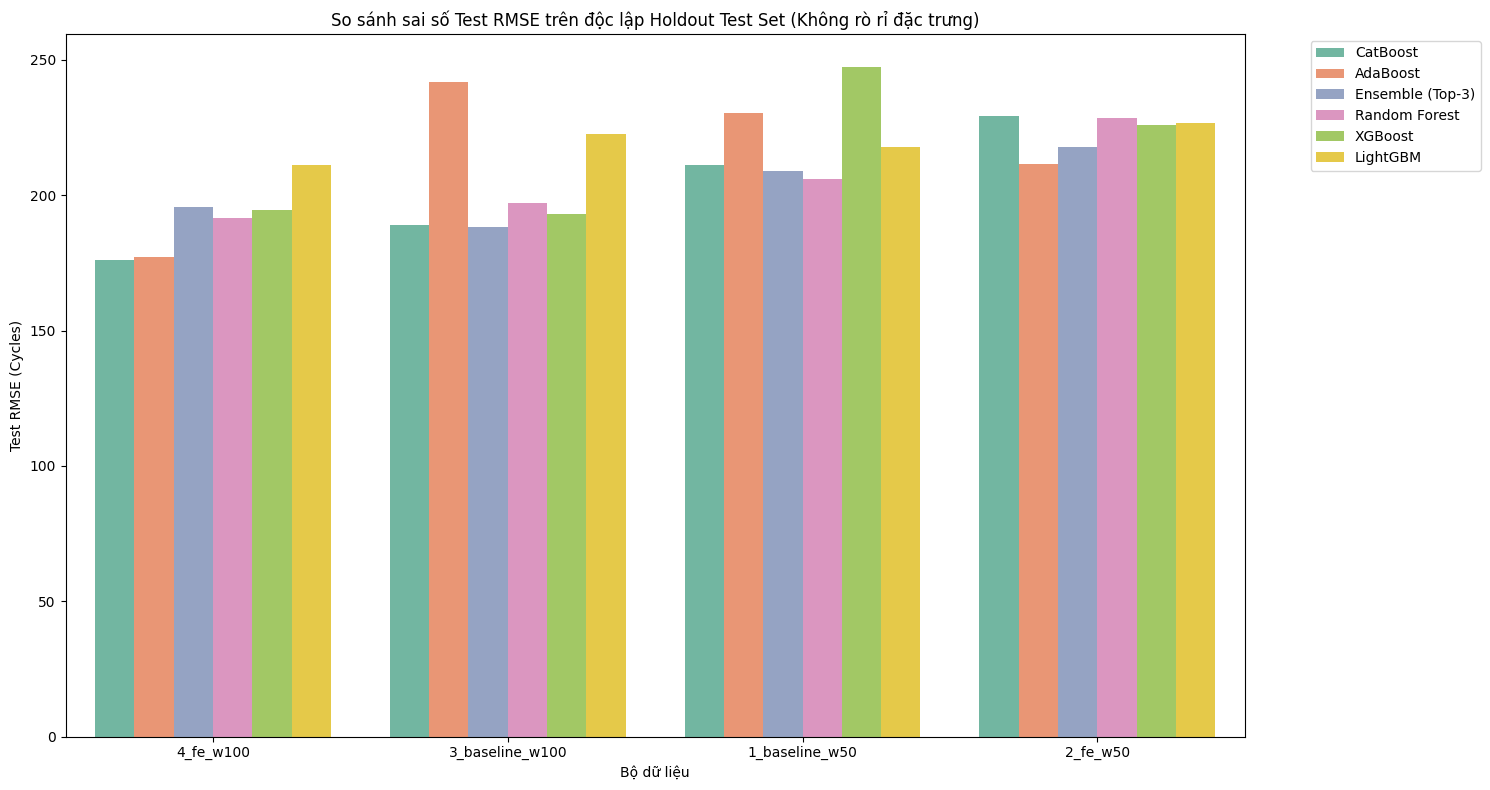

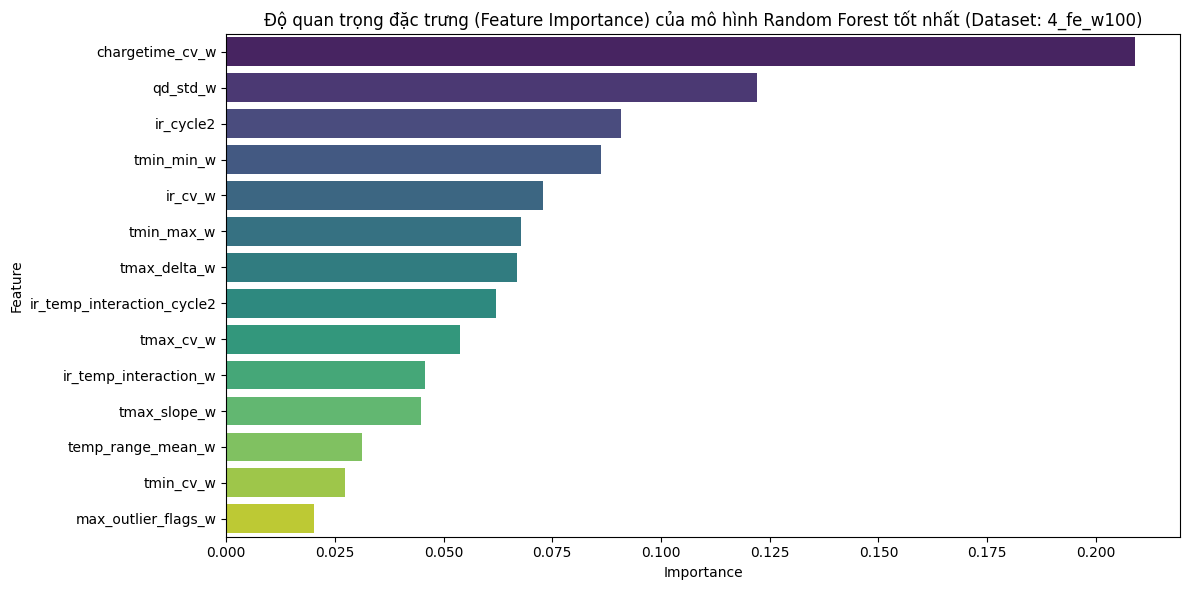

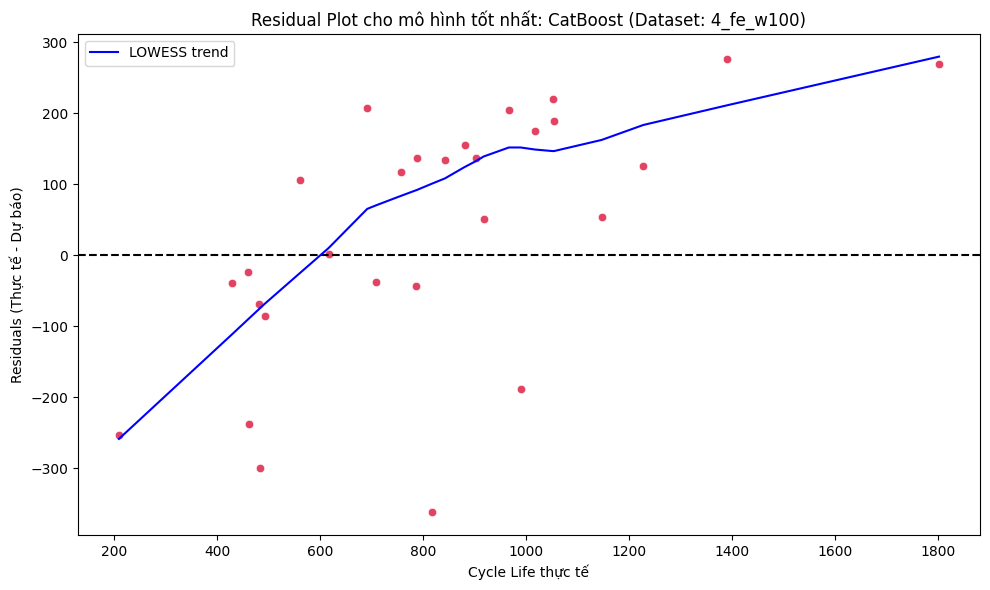

In [9]:
df_final = pd.DataFrame(test_results)
df_final = df_final.sort_values('Test_RMSE').reset_index(drop=True)

print("\n" + "="*105)
print("BẢNG KẾT QUẢ SO SÁNH HIỆU NĂNG HOÀN TOÀN KHÔNG RÒ RỈ (Tuning + Holdout Test set)")
print("="*105)
print(df_final.to_string(columns=['Dataset', 'Model', 'CV_RMSE_mean', 'CV_RMSE_std', 'CV_MAPE', 'Test_RMSE', 'Test_MAE', 'Test_MAPE', 'Test_R2']))
print("="*105)

# Plot 1: Model Comparison
plt.figure(figsize=(15, 8))
df_plot = df_final.copy()
df_plot['CV_Label'] = df_plot.apply(lambda r: f"{r['CV_RMSE_mean']:.1f} ± {r['CV_RMSE_std']:.1f}", axis=1)

ax = sns.barplot(
    data=df_plot,
    x='Dataset',
    y='Test_RMSE',
    hue='Model',
    palette='Set2'
)
plt.title('So sánh sai số Test RMSE trên độc lập Holdout Test Set (Không rò rỉ đặc trưng)')
plt.ylabel('Test RMSE (Cycles)')
plt.xlabel('Bộ dữ liệu')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../plots/model_comparison.png', dpi=150)
plt.show()

# Plot 2: Feature Importance for best RF model
if final_best_rf_model is not None and final_best_rf_features is not None:
    importances = final_best_rf_model.feature_importances_
    df_imp = pd.DataFrame({
        'Feature': final_best_rf_features,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_imp, x='Importance', y='Feature', palette='viridis')
    plt.title('Độ quan trọng đặc trưng (Feature Importance) của mô hình Random Forest tốt nhất (Dataset: 4_fe_w100)')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.savefig('../plots/feature_importance.png', dpi=150)
    plt.show()

# Plot 3: Residual Plot for the best overall model
best_row = df_final.iloc[0]
best_dataset = best_row['Dataset']
best_model_name = best_row['Model']
best_preds = best_row['Test_Predictions']
y_test = df_test_feats_100['cycle_life'] if 'w100' in best_dataset else df_test_feats_50['cycle_life']
residuals = y_test - best_preds

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=residuals, alpha=0.8, color='crimson')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5)

import statsmodels.api as sm
lowess_res = sm.nonparametric.lowess(residuals, y_test, frac=0.6)
plt.plot(lowess_res[:, 0], lowess_res[:, 1], color='blue', linestyle='-', label='LOWESS trend')

plt.title(f'Residual Plot cho mô hình tốt nhất: {best_model_name} (Dataset: {best_dataset})')
plt.xlabel('Cycle Life thực tế')
plt.ylabel('Residuals (Thực tế - Dự báo)')
plt.legend()
plt.tight_layout()
plt.savefig('../plots/residuals_plot.png', dpi=150)
plt.show()
